# tmm_fast examples

Worked examples for `tmm_fast`. The first two cover the basic call signatures, the rest show
features that the `example_*.py` scripts in the repository root do not: the bundled dispersive
materials, absorption, fitting a stack with autograd, drawing a stack, and moving to the GPU.

Conventions used throughout:

- thicknesses and wavelengths are in **meter**, angles in **radian**
- the first and last layer are the semi-infinite injection and outcoupling media, so their
  thickness is `np.inf`
- refractive indices are `n + 1j*k`, and the outputs `R`, `T` have shape
  `[stacks, angles, wavelengths]`

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import tmm_fast as tmmf
from tmm_fast import materials

## 1. A single stack, and what happens past the critical angle

For a single stack the refractive indices are `[layers, wavelengths]` and the thicknesses
`[layers]`; the stack dimension is added and removed for you.

The injection layer here is much denser than the air it radiates into, so beyond the critical
angle there is nothing to couple into and the stack reflects everything. Layers whose index is
below `n[0] * sin(theta)` then carry an evanescent field, and `tmm_fast` clamps the accumulated
imaginary phase at 35i for numerical stability — the opacity warning below is expected in that
regime rather than a sign of trouble.

c:\Users\alexa\Documents\Python\workspace\tmm_fast\tmm_fast\vectorized_tmm_dispersive_multistack.py:154: UserWarning: Opacity warning. The imaginary part of the refractive index is clamped to 35i for numerical stability.
You might encounter problems with gradient computation...
  warn('Opacity warning. The imaginary part of the refractive index is clamped to 35i for numerical stability.\n'+


injection layer n = 4.46, critical angle = 13.0 deg
R shape (301, 301) | min R beyond the critical angle: 1.000000000


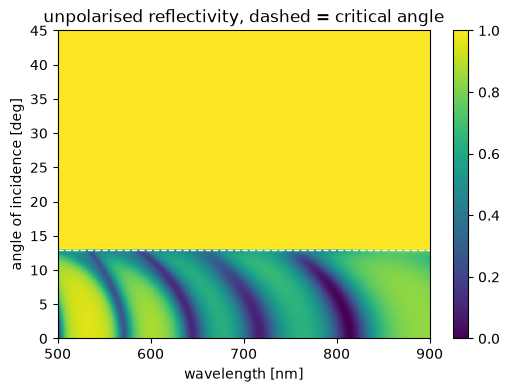

In [2]:
rng = np.random.default_rng(0)
num_layers = 12

d = rng.uniform(20, 150, num_layers) * 1e-9
d[0] = d[-1] = np.inf
n = np.ones((num_layers, 301)) * rng.uniform(1.2, 5, num_layers)[:, None]
n[-1] = 1.0  # outcoupling into air

wl = np.linspace(500, 900, 301) * 1e-9
theta = np.deg2rad(np.linspace(0, 45, 301))

# unpolarised light is the mean of the two polarisations
R = (tmmf.coh_tmm('s', n, d, theta, wl)['R'] + tmmf.coh_tmm('p', n, d, theta, wl)['R']) / 2

critical = np.rad2deg(np.arcsin(1 / n[0, 0].real))
print('injection layer n = %.2f, critical angle = %.1f deg' % (n[0, 0].real, critical))
print('R shape', R.shape, '| min R beyond the critical angle: %.9f' % R[theta > np.deg2rad(critical)].min())

fig, ax = plt.subplots(figsize=(6, 4))
image = ax.imshow(R, aspect='auto', origin='lower', vmin=0, vmax=1,
                  extent=(wl[0] * 1e9, wl[-1] * 1e9, 0, 45))
ax.axhline(critical, color='w', ls='--', lw=1)
ax.set_xlabel('wavelength [nm]')
ax.set_ylabel('angle of incidence [deg]')
ax.set_title('unpolarised reflectivity, dashed = critical angle')
fig.colorbar(image, ax=ax)
plt.show()

## 2. Many stacks in one call

The point of the package: pass a batch of stacks and get every combination of stack, angle and
wavelength back from a single vectorised call.

R shape [stacks, angles, wavelengths]: (128, 45, 800)


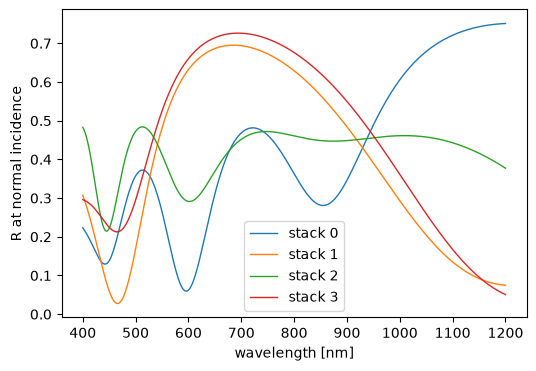

In [3]:
wl = np.linspace(400, 1200, 800) * 1e-9
theta = np.deg2rad(np.linspace(0, 89, 45))
num_stacks, num_layers = 128, 6

N = np.ones((num_stacks, num_layers, wl.size))
N[:, 1:-1:2] = 1.46
N[:, 2:-1:2] = 2.56

D = rng.uniform(10, 150, (num_stacks, num_layers)) * 1e-9
D[:, 0] = D[:, -1] = np.inf

out = tmmf.coh_tmm('s', N, D, theta, wl)
print('R shape [stacks, angles, wavelengths]:', out['R'].shape)

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(4):
    ax.plot(wl * 1e9, out['R'][i, 0], lw=1, label='stack %d' % i)
ax.set_xlabel('wavelength [nm]')
ax.set_ylabel('R at normal incidence')
ax.legend()
plt.show()

## 3. Dispersive materials shipped with the package

`tmm_fast.materials` carries tabulated indices for a few common materials and interpolates them
onto the wavelengths you ask for. Wavelengths go in as meter; passing nanometer by mistake raises
instead of silently returning nonsense.

bundled materials: ['Au', 'Nb2O5', 'SiO2']


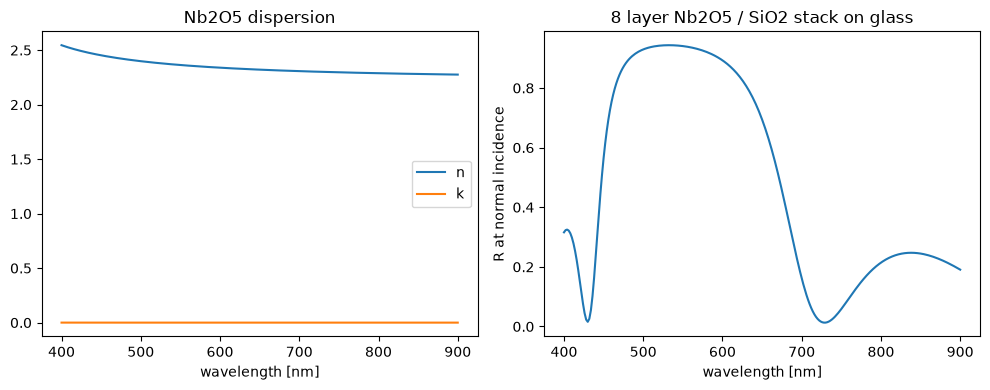

In [4]:
print('bundled materials:', materials.available())

wl = np.linspace(400, 900, 251) * 1e-9
coating = ['Nb2O5', 'SiO2'] * 4

N = np.vstack([np.ones_like(wl)]
              + [materials.load(m, wl) for m in coating]
              + [materials.load('SiO2', wl)])[None]
D = np.array([[np.inf] + [55e-9, 95e-9] * 4 + [np.inf]])

out = tmmf.coh_tmm('s', N, D, np.array([0.0]), wl)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
n_Nb2O5 = materials.load('Nb2O5', wl)
axs[0].plot(wl * 1e9, n_Nb2O5.real, label='n')
axs[0].plot(wl * 1e9, n_Nb2O5.imag, label='k')
axs[0].set_title('Nb2O5 dispersion')
axs[0].set_xlabel('wavelength [nm]')
axs[0].legend()

axs[1].plot(wl * 1e9, out['R'][0, 0])
axs[1].set_title('8 layer Nb2O5 / SiO2 stack on glass')
axs[1].set_xlabel('wavelength [nm]')
axs[1].set_ylabel('R at normal incidence')
plt.tight_layout()
plt.show()

## 4. Absorption

`coh_tmm` returns reflectivity and transmissivity; whatever is missing was absorbed, so
`A = 1 - R - T`. A thin gold film makes the point.

R + T + A deviates from 1 by at most 1.11e-16


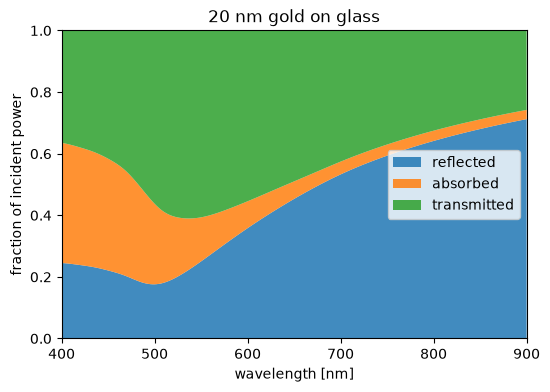

In [5]:
wl = np.linspace(400, 900, 251) * 1e-9
N = np.vstack([np.ones_like(wl), materials.load('Au', wl), materials.load('SiO2', wl)])[None]
D = np.array([[np.inf, 20e-9, np.inf]])

out = tmmf.coh_tmm('s', N, D, np.array([0.0]), wl)
R, T = out['R'][0, 0], out['T'][0, 0]
A = 1 - R - T
print('R + T + A deviates from 1 by at most %.2e' % np.abs(R + T + A - 1).max())

fig, ax = plt.subplots(figsize=(6, 4))
ax.stackplot(wl * 1e9, R, A, T, labels=['reflected', 'absorbed', 'transmitted'], alpha=0.85)
ax.set_xlabel('wavelength [nm]')
ax.set_ylabel('fraction of incident power')
ax.set_title('20 nm gold on glass')
ax.set_xlim(wl[0] * 1e9, wl[-1] * 1e9)
ax.set_ylim(0, 1)
ax.legend(loc='center right')
plt.show()

## 5. Fitting a stack with autograd

Everything above runs through PyTorch, so the result is differentiable with respect to the layer
thicknesses. Passing torch tensors instead of numpy arrays is enough to get gradients, which turns
coating design into plain gradient descent.

Two things worth copying from this cell: the semi-infinite `inf` edges are concatenated onto the
learnable parameters rather than assigned into them, because in-place assignment into a tensor that
requires grad is an error; and the thicknesses are parameterised in nanometer, which keeps the
gradients at a sane magnitude.

mean R  0.08426 -> 0.01855   (uncoated glass 0.04258)
thicknesses [nm]: [109.9, 138.1, 5.0]


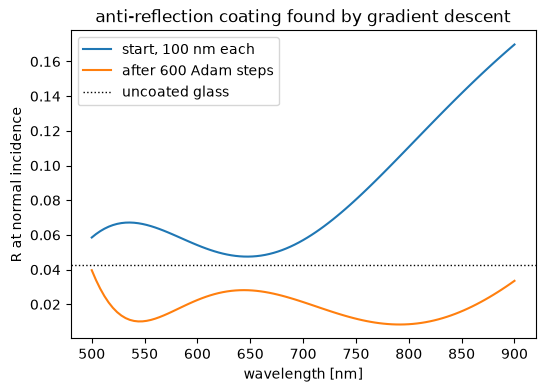

In [6]:
wl = torch.linspace(500e-9, 900e-9, 101, dtype=torch.float64)
theta = torch.tensor([0.0], dtype=torch.float64)

layers = [1.0, 1.46, 2.35, 1.46, 1.52]  # air / coating / glass
N = torch.tensor(layers, dtype=torch.complex128)[None, :, None].repeat(1, 1, len(wl))
edge = torch.full((1, 1), float('inf'), dtype=torch.float64)

d_nm = torch.full((len(layers) - 2,), 100.0, dtype=torch.float64, requires_grad=True)


def reflectivity(thickness_nm):
    D = torch.cat([edge, (thickness_nm * 1e-9).unsqueeze(0), edge], dim=1)
    return tmmf.coh_tmm('s', N, D, theta, wl)['R']


R_start = reflectivity(d_nm).detach().clone()

optimizer = torch.optim.Adam([d_nm], lr=2.0)
for step in range(600):
    optimizer.zero_grad()
    loss = (reflectivity(d_nm) ** 2).mean()
    loss.backward()
    optimizer.step()
    with torch.no_grad():
        d_nm.clamp_(5.0, 400.0)

R_end = reflectivity(d_nm).detach()
bare_glass = ((1 - 1.52) / (1 + 1.52)) ** 2

print('mean R  %.5f -> %.5f   (uncoated glass %.5f)' % (R_start.mean(), R_end.mean(), bare_glass))
print('thicknesses [nm]:', [round(v, 1) for v in d_nm.detach().tolist()])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(wl * 1e9, R_start[0, 0], label='start, 100 nm each')
ax.plot(wl * 1e9, R_end[0, 0], label='after 600 Adam steps')
ax.axhline(bare_glass, color='k', ls=':', lw=1, label='uncoated glass')
ax.set_xlabel('wavelength [nm]')
ax.set_ylabel('R at normal incidence')
ax.set_title('anti-reflection coating found by gradient descent')
ax.legend()
plt.show()

## 6. Drawing the stack

`plot_stacks` sketches the layers to scale, coloured by refractive index. It takes thicknesses in
meter and returns the axes plus the colormap.

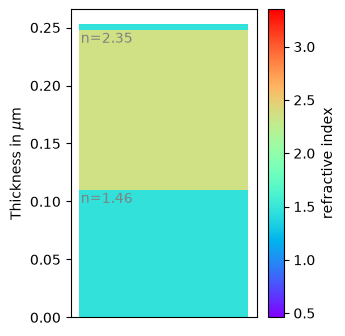

In [7]:
fig, ax = plt.subplots(figsize=(3, 4))
indices = np.array(layers[1:-1], dtype=float)
thicknesses = d_nm.detach().numpy() * 1e-9

ax, cmap = tmmf.plot_stacks(ax, indices, thicknesses, labels='fitted coating')
fig.colorbar(cmap, ax=ax, label='refractive index')
plt.show()

## 7. Running on the GPU

Pass `device='cuda'` to move the computation to the GPU, which pays off once the batch of stacks,
angles and wavelengths gets large. Note that the default is `'cpu'`, so cuda tensors handed in
without this argument are copied back to the host.

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('cuda available:', torch.cuda.is_available(), '-> running on', device)

wl = np.linspace(400, 900, 251) * 1e-9
N = np.vstack([np.ones_like(wl), materials.load('Nb2O5', wl), materials.load('SiO2', wl)])[None]
D = np.array([[np.inf, 120e-9, np.inf]])

out = tmmf.coh_tmm('s', N, D, np.deg2rad(np.linspace(0, 80, 64)), wl, device=device)
print('R shape', out['R'].shape, '| mean R %.4f' % out['R'].mean())

cuda available: False -> running on cpu
R shape (1, 64, 251) | mean R 0.3360


c:\Users\alexa\Documents\Python\workspace\tmm_fast\tmm_fast\vectorized_tmm_dispersive_multistack.py:154: UserWarning: Opacity warning. The imaginary part of the refractive index is clamped to 35i for numerical stability.
You might encounter problems with gradient computation...
  warn('Opacity warning. The imaginary part of the refractive index is clamped to 35i for numerical stability.\n'+
